# D2C Customer Churn Intelligence & Retention API
## Part 1: Data Audit & Exploratory Data Analysis

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('ggplot')
%matplotlib inline

In [4]:
customers = pd.read_csv('/content/customers.csv')
orders = pd.read_csv('/content/orders.csv')
support = pd.read_csv('/content/support_tickets.csv')
web = pd.read_csv('/content/web_events_snapshot.csv')
churn = pd.read_csv('/content/churn_labels.csv')
intervention = pd.read_csv('/content/intervention_history.csv')

In [5]:
datasets = {
    'customers': customers,
    'orders': orders,
    'support': support,
    'web': web,
    'churn': churn,
    'intervention': intervention
}

for name, df in datasets.items():
    print("="*50)
    print(name.upper())
    print("Shape:", df.shape)
    print(df.head())
    print()

CUSTOMERS
Shape: (2400, 9)
  customer_id signup_date city_tier age_group acquisition_channel  \
0   CUST00001  2024-04-24    Tier 1     18-24           Instagram   
1   CUST00002  2025-06-01    Tier 2     25-34         Marketplace   
2   CUST00003  2025-03-08    Tier 1     25-34          Influencer   
3   CUST00004  2025-04-15    Tier 3     25-34       Google Search   
4   CUST00005  2024-08-21    Tier 3     35-44             Organic   

  loyalty_tier preferred_category    skin_type marketing_consent  
0       Silver             Makeup       Normal               Yes  
1       Silver          Hair Care  Combination               Yes  
2          NaN          Skin Care         Oily               Yes  
3          NaN          Fragrance       Normal                No  
4         Gold          Hair Care  Combination               Yes  

ORDERS
Shape: (10009, 10)
    order_id customer_id  order_date   category  quantity  gross_amount  \
0  ORD000001   CUST00001  2024-08-06  Skin Care       

In [6]:
for name, df in datasets.items():
    print("="*60)
    print(name.upper())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicates:")
    print(df.duplicated().sum())

    print("\nData Types:")
    print(df.dtypes)
    print()

CUSTOMERS

Missing Values:
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

Duplicates:
0

Data Types:
customer_id            object
signup_date            object
city_tier              object
age_group              object
acquisition_channel    object
loyalty_tier           object
preferred_category     object
skin_type              object
marketing_consent      object
dtype: object

ORDERS

Missing Values:
order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

Duplicates:
0

Data Types:
order_id          object
customer_id       object
order_date        object
category          object
quantity           int64
gross

In [7]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
support['ticket_date'] = pd.to_datetime(support['ticket_date'])

In [8]:
snapshot_date = pd.Timestamp('2025-09-30')

post_snapshot = orders[
    orders['order_date'] > snapshot_date
]

print("Post-snapshot orders:", len(post_snapshot))

Post-snapshot orders: 1872


In [9]:
dup_orders = orders[
    orders['order_id'].str.contains('_DUP', na=False)
]

print("Duplicate-like records:", len(dup_orders))
dup_orders.head()

Duplicate-like records: 12


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0
3602,ORD002916_DUP,CUST00848,2025-09-26,Skin Care,1,547.18,0.28,2,0,5.0
3675,ORD002970_DUP,CUST00869,2024-12-22,Fragrance,1,818.64,0.18,2,0,4.0


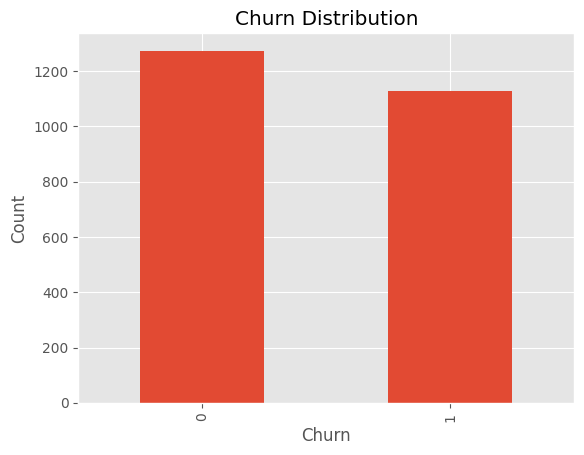

In [10]:
churn['churn_next_60d'].value_counts().plot(
    kind='bar'
)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

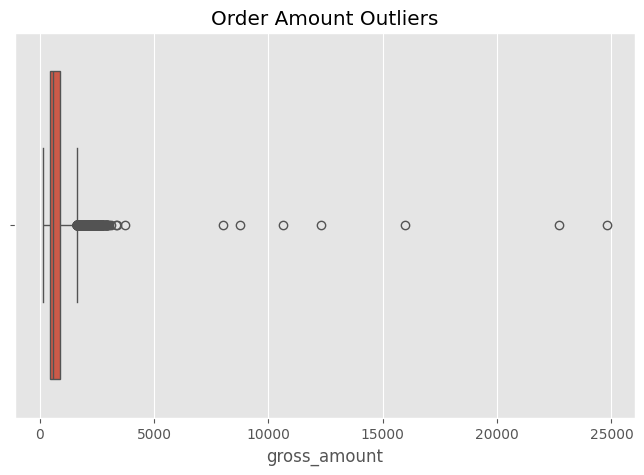

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=orders['gross_amount'])
plt.title("Order Amount Outliers")
plt.show()

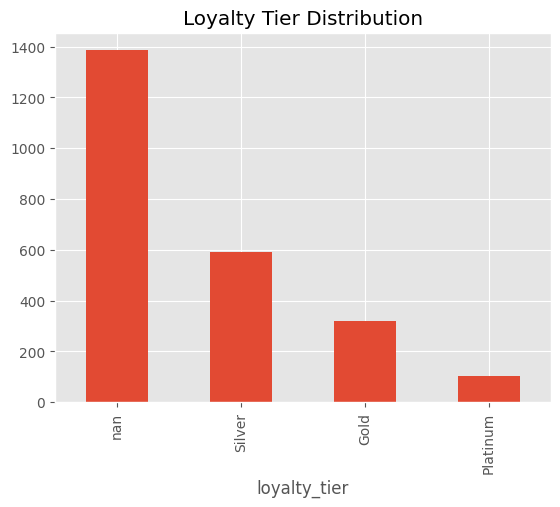

In [12]:
customers['loyalty_tier'].value_counts(dropna=False).plot(
    kind='bar'
)

plt.title("Loyalty Tier Distribution")
plt.show()

In [13]:
df = customers.merge(churn, on='customer_id', how='left')

print(df.shape)
df.head()

(2400, 12)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train


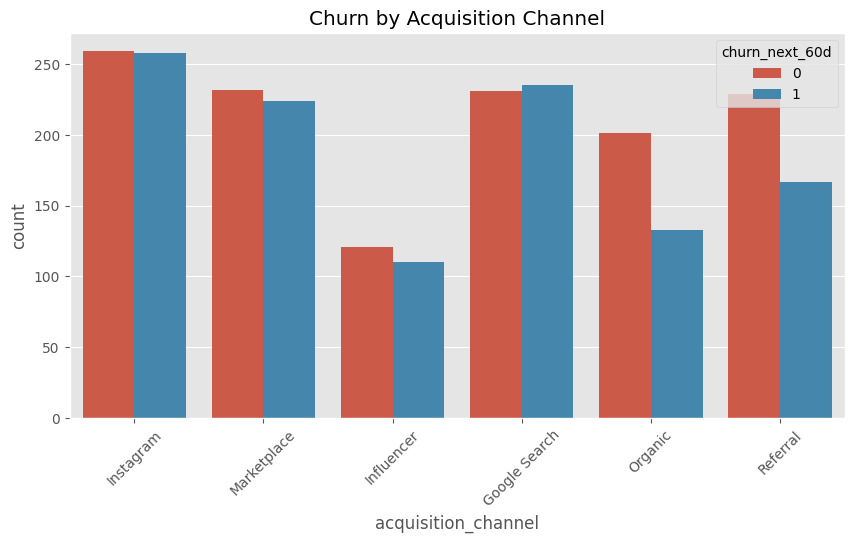

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='acquisition_channel', hue='churn_next_60d')
plt.xticks(rotation=45)
plt.title("Churn by Acquisition Channel")
plt.show()

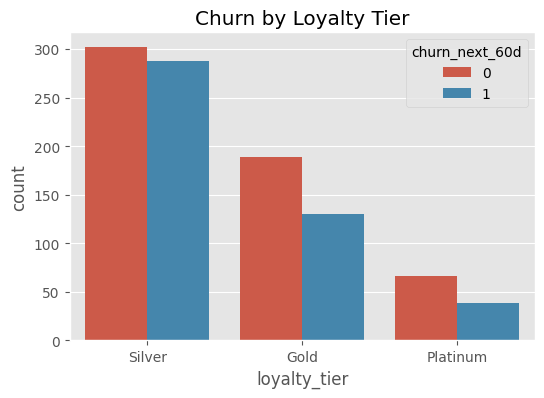

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='loyalty_tier', hue='churn_next_60d')
plt.title("Churn by Loyalty Tier")
plt.show()

## Hypothesis 4: Loyalty Programs Improve Customer Retention
Customers enrolled in loyalty programs appear to have lower churn rates.

**Business Implication:** Encourage loyalty enrollment.

In [16]:
snapshot_date = pd.Timestamp('2025-09-30')

orders_pre = orders[
    orders['order_date'] <= snapshot_date
]

In [17]:
customer_spend = (
    orders_pre.groupby('customer_id')['gross_amount']
    .sum()
    .reset_index()
)

customer_spend.rename(
    columns={'gross_amount':'total_spend'},
    inplace=True
)

df = df.merge(customer_spend,
              on='customer_id',
              how='left')

df['total_spend'].fillna(0, inplace=True)

/tmp/ipykernel_1109/3333810763.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_spend'].fillna(0, inplace=True)


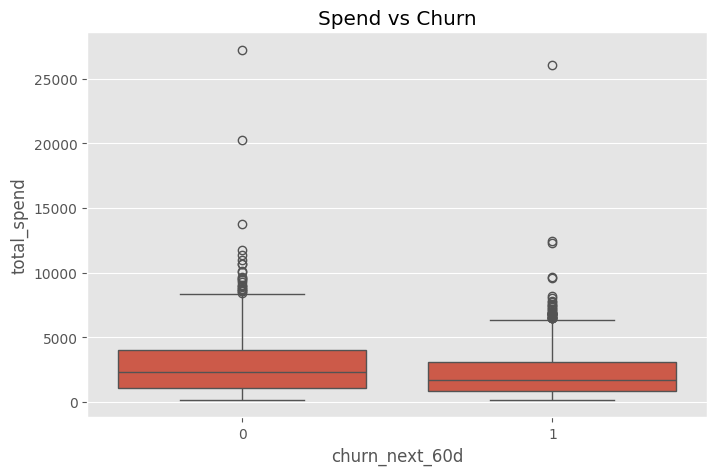

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='churn_next_60d',
    y='total_spend'
)
plt.title("Spend vs Churn")
plt.show()

## Hypothesis 3: Low Spending Customers Are More Likely to Churn
Customers with lower total spending tend to churn more frequently. High-value customers are generally more engaged and loyal.

**Business Implication:** Target low-spending customers with personalized offers.

In [19]:
ticket_count = (
    support.groupby('customer_id')
    .size()
    .reset_index(name='ticket_count')
)

df = df.merge(
    ticket_count,
    on='customer_id',
    how='left'
)

df['ticket_count'].fillna(0, inplace=True)

/tmp/ipykernel_1109/1090044761.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ticket_count'].fillna(0, inplace=True)


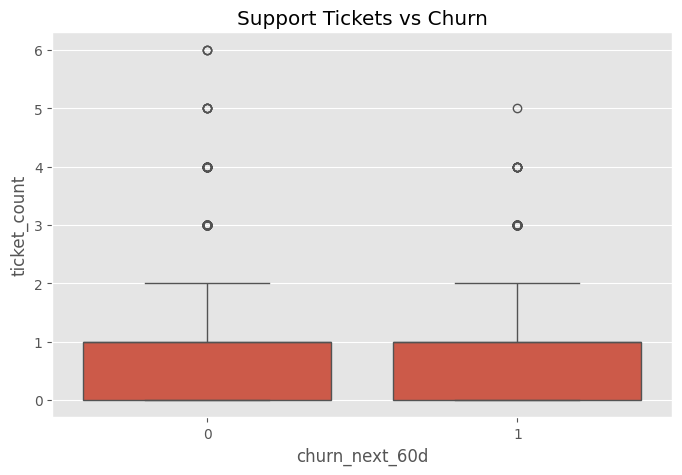

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='churn_next_60d',
    y='ticket_count'
)
plt.title("Support Tickets vs Churn")
plt.show()

## Hypothesis 2: Frequent Support Issues Increase Churn Risk
Customers with a higher number of support tickets appear to exhibit greater churn risk.

**Business Implication:** Improve support quality and reduce resolution time.

In [21]:
df = df.merge(
    web,
    on='customer_id',
    how='left'
)

In [24]:
df.columns.tolist()

['customer_id',
 'signup_date',
 'city_tier',
 'age_group',
 'acquisition_channel',
 'loyalty_tier',
 'preferred_category',
 'skin_type',
 'marketing_consent',
 'snapshot_date_x',
 'churn_next_60d',
 'split',
 'total_spend',
 'ticket_count',
 'snapshot_date_y',
 'sessions_30d_x',
 'product_views_30d_x',
 'cart_adds_30d_x',
 'wishlist_adds_30d_x',
 'abandoned_carts_30d_x',
 'email_opens_30d_x',
 'campaign_clicks_30d_x',
 'last_visit_days_ago_x',
 'snapshot_date',
 'sessions_30d_y',
 'product_views_30d_y',
 'cart_adds_30d_y',
 'wishlist_adds_30d_y',
 'abandoned_carts_30d_y',
 'email_opens_30d_y',
 'campaign_clicks_30d_y',
 'last_visit_days_ago_y']

In [25]:
# Keep one copy
df['sessions_30d'] = df['sessions_30d_x']
df['product_views_30d'] = df['product_views_30d_x']
df['cart_adds_30d'] = df['cart_adds_30d_x']
df['wishlist_adds_30d'] = df['wishlist_adds_30d_x']
df['abandoned_carts_30d'] = df['abandoned_carts_30d_x']
df['email_opens_30d'] = df['email_opens_30d_x']
df['campaign_clicks_30d'] = df['campaign_clicks_30d_x']
df['last_visit_days_ago'] = df['last_visit_days_ago_x']

# Drop duplicate columns
df = df.drop(columns=[
    'snapshot_date_x',
    'snapshot_date_y',
    'snapshot_date',
    'sessions_30d_x',
    'sessions_30d_y',
    'product_views_30d_x',
    'product_views_30d_y',
    'cart_adds_30d_x',
    'cart_adds_30d_y',
    'wishlist_adds_30d_x',
    'wishlist_adds_30d_y',
    'abandoned_carts_30d_x',
    'abandoned_carts_30d_y',
    'email_opens_30d_x',
    'email_opens_30d_y',
    'campaign_clicks_30d_x',
    'campaign_clicks_30d_y',
    'last_visit_days_ago_x',
    'last_visit_days_ago_y'
])

print(df.columns)

Index(['customer_id', 'signup_date', 'city_tier', 'age_group',
       'acquisition_channel', 'loyalty_tier', 'preferred_category',
       'skin_type', 'marketing_consent', 'churn_next_60d', 'split',
       'total_spend', 'ticket_count', 'sessions_30d', 'product_views_30d',
       'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d',
       'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago'],
      dtype='object')


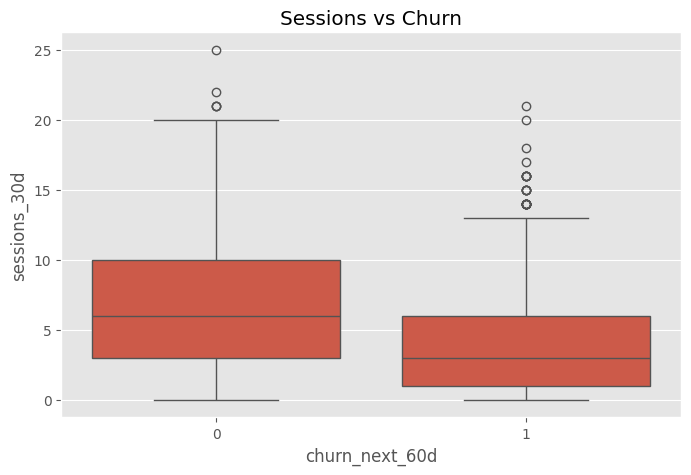

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='churn_next_60d',
    y='sessions_30d'
)
plt.title("Sessions vs Churn")
plt.show()

## Hypothesis 1: Low Web Activity Increases Churn Risk
Customers with lower sessions_30d appear more likely to churn.

**Business Implication:** Launch re-engagement campaigns.

In [28]:
df = df.merge(intervention, on='customer_id', how='left')

In [32]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='last_campaign_received',
    hue='churn_next_60d'
)

plt.xticks(rotation=45)
plt.title("Campaign vs Churn")
plt.show()


ValueError: Could not interpret value `last_campaign_received` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

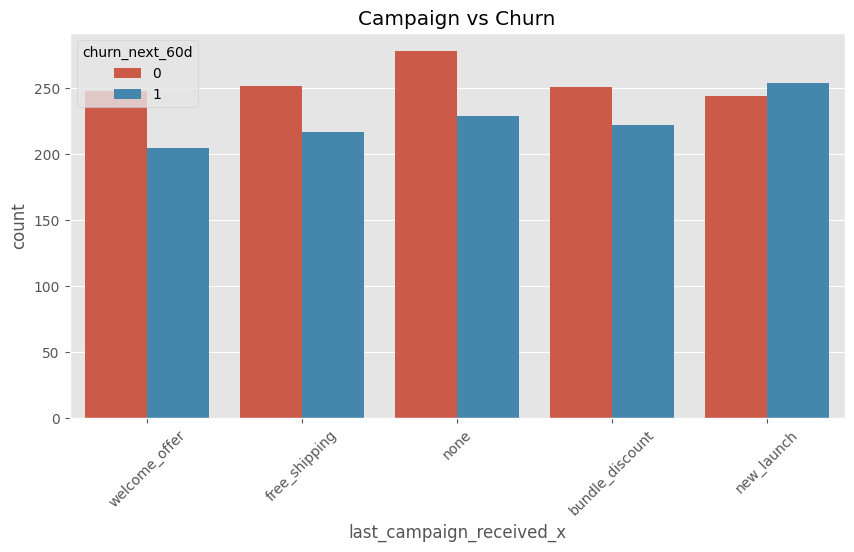

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='last_campaign_received_x',
    hue='churn_next_60d'
)

plt.xticks(rotation=45)
plt.title("Campaign vs Churn")
plt.show()

## Hypothesis 6: Marketing Campaigns Influence Customer Retention
Different campaigns show different churn patterns.

**Business Implication:** Evaluate campaign effectiveness.

In [35]:
# Keep one copy
df['last_campaign_received'] = df['last_campaign_received_x']
df['last_campaign_cost'] = df['last_campaign_cost_x']
df['manual_priority_bucket'] = df['manual_priority_bucket_x']

# Drop duplicates
df = df.drop(columns=[
    'snapshot_date_x',
    'snapshot_date_y',
    'last_campaign_received_x',
    'last_campaign_received_y',
    'last_campaign_cost_x',
    'last_campaign_cost_y',
    'manual_priority_bucket_x',
    'manual_priority_bucket_y'
])

print(df.columns.tolist())

['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent', 'churn_next_60d', 'split', 'total_spend', 'ticket_count', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'last_campaign_received', 'last_campaign_cost', 'manual_priority_bucket']


In [36]:
return_rate = (
    orders_pre.groupby('customer_id')['returned']
    .mean()
    .reset_index()
)

df = df.merge(
    return_rate,
    on='customer_id',
    how='left'
)

df['returned'].fillna(0, inplace=True)

/tmp/ipykernel_1109/3080616009.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['returned'].fillna(0, inplace=True)


In [38]:
print(df.columns.tolist())

['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent', 'churn_next_60d', 'split', 'total_spend', 'ticket_count', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'last_campaign_received', 'last_campaign_cost', 'manual_priority_bucket', 'returned_x', 'returned_y']


In [39]:
# Keep one copy
df['returned'] = df['returned_x']

# Remove duplicate columns
df = df.drop(columns=['returned_x', 'returned_y'])

print(df.columns.tolist())

['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent', 'churn_next_60d', 'split', 'total_spend', 'ticket_count', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'last_campaign_received', 'last_campaign_cost', 'manual_priority_bucket', 'returned']


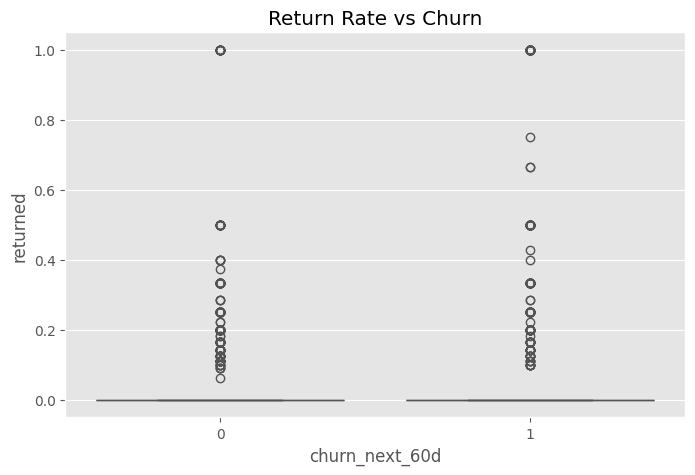

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='churn_next_60d',
    y='returned'
)

plt.title("Return Rate vs Churn")
plt.show()

## Hypothesis 5: High Return Rates Are Associated with Customer Churn
Customers with higher return rates appear more likely to churn.

**Business Implication:** Investigate reasons for returns.